# Dissemination Areas Boundaries

It is necessary to explore the **Dissemination Areas** boundaries dataset in order to perform spatial analysis during the EDA of each characteristic of interest. 

According to the [Dictionary, Census of Population, 2021: Census tract (CT)](https://www12.statcan.gc.ca/census-recensement/2021/ref/dict/az/Definition-eng.cfm?ID=geo013), a Census tract (CT) is defined as a small and  relatively stable geographic area often, with fewer than 7,500 people, based on previous census of population. CTs are defined by Statistics Canada to support census and survey dissemination activities and should be used with caution for non‑statistical purposes.

The boundary file used in this project represents only the geographic areas and excludes coastal water areas. This type of file is referred to as a cartographic boundary file. It is available at [2021 Census – Boundary files](https://www12.statcan.gc.ca/census-recensement/2021/geo/sip-pis/boundary-limites/index2021-eng.cfm?year=21). Previous versions are also accessible.

In [ ]:
# import libraries
import pandas as pd
import duckdb

In [ ]:
# show all columns
pd.set_option('display.max_columns', None)

## Create a DuckDB database with the dataset

The file `lda_000b21s_e.csv.gz` has a ~11mb file size. Since our previous database was built on ducdb. We will keep using it. DuckDB dataset will make it easy to make any process and transformation using SQL queries.

In [ ]:
# Create a DuckDB database
raw_con = duckdb.connect("data/database/raw.duckdb")

### Exploring a sample

In [ ]:
# detect csv config
df = raw_con.execute("""
    SELECT *
    FROM sniff_csv(
        ?,
        encoding='cp1252',
        delim=',',
        sample_size=20480
    )
""", ["data/raw/da_c2021_dataset.csv.gz"]).fetchdf()

print(df.T)

                                                                  0
Delimiter                                                         ,
Quote                                                             "
Escape                                                            "
NewLineDelimiter                                               \r\n
Comment                                                     (empty)
SkipRows                                                          0
HasHeader                                                      True
Columns           [{'name': 'CENSUS_YEAR', 'type': 'BIGINT'}, {'...
DateFormat                                                     None
TimestampFormat                                                None
UserArguments       delim=',', encoding='cp1252', sample_size=20480
Prompt            FROM read_csv('data/raw/da_c2021_dataset.csv.g...


In [ ]:
# return the read_csv config 
prompt = df["Prompt"].iloc[0]
prompt = prompt[:-1]
prompt

'FROM read_csv(\'data/raw/da_c2021_dataset.csv.gz\', auto_detect=false, quote=\'"\', escape=\'"\', new_line=\'\\r\\n\', skip=0, comment=\'\', header=true, columns={\'CENSUS_YEAR\': \'BIGINT\', \'DGUID\': \'VARCHAR\', \'ALT_GEO_CODE\': \'VARCHAR\', \'GEO_LEVEL\': \'VARCHAR\', \'GEO_NAME\': \'VARCHAR\', \'TNR_SF\': \'DOUBLE\', \'TNR_LF\': \'DOUBLE\', \'DATA_QUALITY_FLAG\': \'VARCHAR\', \'CHARACTERISTIC_ID\': \'BIGINT\', \'CHARACTERISTIC_NAME\': \'VARCHAR\', \'CHARACTERISTIC_NOTE\': \'BIGINT\', \'C1_COUNT_TOTAL\': \'DOUBLE\', \'SYMBOL\': \'VARCHAR\', \'C2_COUNT_MEN+\': \'DOUBLE\', \'SYMBOL_1\': \'VARCHAR\', \'C3_COUNT_WOMEN+\': \'DOUBLE\', \'SYMBOL_2\': \'VARCHAR\', \'C10_RATE_TOTAL\': \'DOUBLE\', \'SYMBOL_3\': \'VARCHAR\', \'C11_RATE_MEN+\': \'DOUBLE\', \'SYMBOL_4\': \'VARCHAR\', \'C12_RATE_WOMEN+\': \'DOUBLE\', \'SYMBOL_5\': \'VARCHAR\'}, delim=\',\', encoding=\'cp1252\', sample_size=20480)'

In [ ]:
# import shp file
gdf = gpd.read_file(f"zip://{"lda_000b21s_e.zip"}")

In [ ]:
gdf.head()

,DAUID,DGUID,LANDAREA,PRUID,SHAPE_Leng,SHAPE_Area,geometry
0,35140110,2021S051235140110,44.2501,35,31910.622845,4.662526e+07,"POLYGON ((7342762.9 1038223.437, 7342930.369 1..."
1,35140111,2021S051235140111,37.5066,35,38065.549293,4.253406e+07,"POLYGON ((7340258.371 1035059.977, 7340521.903..."
2,35140112,2021S051235140112,17.5309,35,22627.459928,1.826862e+07,"POLYGON ((7341934.177 1032291.431, 7342677.317..."
3,35140113,2021S051235140113,18.7260,35,23064.876177,1.951867e+07,"POLYGON ((7342858.174 1029966.357, 7343046.869..."
4,35140114,2021S051235140114,0.3530,35,3659.163371,3.678721e+05,"POLYGON ((7337124.629 1028489.003, 7337242.869..."


In [ ]:
gdf.shape

(13130, 7)

In [ ]:
gdf.dtypes

DAUID           object
DGUID           object
LANDAREA       float64
PRUID           object
SHAPE_Leng     float64
SHAPE_Area     float64
geometry      geometry
dtype: object

In [ ]:
# coordinate reference system specs
print(gdf.crs,gdf.crs.name) 

EPSG:3347 NAD83 / Statistics Canada Lambert


The dataset has a projected crs, and its units are in meters.

## Data dictionary

The DAa boundary file has an 6 column by 6247 rows dataframe. It's dictionary is found in the [Boundary Files, Reference Guide, Second edition, Census year 2021](https://www150.statcan.gc.ca/n1/pub/92-160-g/92-160-g2021002-eng.htm).

Attribute name | Description | Dtype
---------------|-------------|--
DAUID | Uniquely identifies a census tract (CT) within a census metropolitan area (CMA) or census agglomeration (CM). <br> It is composed by the 3-digit CMA or CM unique identifier followed by the 7.2-character CT name. | Character (10)
DGUID | Dissemination Geography Unique Identifier. | Character (21)
LANDAREA | Land area of geographic area, in square kilometres (km2). | Number (12.4)
PRUID | Uniquely identifies a province or territory. <br>The full list is available at [2021 Census—Attribute domain values: Provinces and territories (PRUID)](https://www12.statcan.gc.ca/census-recensement/2021/geo/ref/domain-domaine/index2021-eng.cfm?lang=e&id=PRUID) | Character (2)

Based on the column descriptions, only the variables `DGUID` and `LANDAREA` are relevant. The remaining variables can be dropped.

In [ ]:
gdf=gdf.drop(columns=["DAUID","PRUID","SHAPE_Leng","SHAPE_Area"]).copy()

In [ ]:
gdf.head()

,DGUID,LANDAREA,geometry
0,2021S051235140110,44.2501,"POLYGON ((7342762.9 1038223.437, 7342930.369 1..."
1,2021S051235140111,37.5066,"POLYGON ((7340258.371 1035059.977, 7340521.903..."
2,2021S051235140112,17.5309,"POLYGON ((7341934.177 1032291.431, 7342677.317..."
3,2021S051235140113,18.7260,"POLYGON ((7342858.174 1029966.357, 7343046.869..."
4,2021S051235140114,0.3530,"POLYGON ((7337124.629 1028489.003, 7337242.869..."


In [ ]:
gdf.shape

(13130, 3)

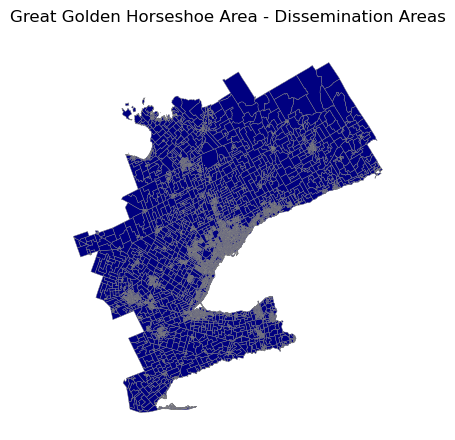

In [ ]:
# basic plot
gdf.plot(
    figsize=(5,5), color='navy', edgecolor='grey', linewidth=0.3
)

plt.title("Great Golden Horseshoe Area - Dissemination Areas")
plt.axis('off')

plt.show()

The primary key that bind the Census of Population and Census Tract datasets is the `DGUID` column. Joining the Census Tract dataset will allow the addition of geometry values to any  population subset in this analysis. Join operations will be performed in a controlled manner to ensure that performance is not compromised and only when a map visualization or spatial analysis is needed.

The **Toronto Census Metropolitan Area (CMA)** contain more than just the city of Toronto boundary. It also contains Scarborough, Missisauga, Orangeville, Vaughan, Markham and extends north to Georgina Island. It is important to note that, when defining the area of interest, a decision must be made whether to focus solely on the City of Toronto or to use the entire Toronto CMA as defined.

# Resouces

- [Census Profile, 2021 Census of Population](https://www12.statcan.gc.ca/census-recensement/2021/dp-pd/prof/index.cfm?Lang=E)
- [About the Census Profile, 2021 Census of Population](https://www12.statcan.gc.ca/census-recensement/2021/dp-pd/prof/about-apropos/about-apropos.cfm?Lang=E#aa1)
- [Guide to the Census of Population, 2021](https://www12.statcan.gc.ca/census-recensement/2021/ref/98-304/index-eng.cfm),  provides an overview of the Census of Population content determination, collection, processing, data quality assessment and data dissemination. It may be useful to both new and experienced users who wish to familiarize themselves with and find specific information about the 2021 Census
- [Filling the gaps: Information on gender in the 2021 Census](https://www12.statcan.gc.ca/census-recensement/2021/ref/98-20-0001/982000012021001-eng.cfm), defines gender, sex at birth, and relevant concepts as the Census 2021 disseminates census information on gender
- [Census Profile metadata](https://www12.statcan.gc.ca/census-recensement/2021/dp-pd/prof/about-apropos/metadata-metadonnees-eng.cfm), list characteristics by topics and subtopic, and list all footnotes
- [Full Table Download (CSV) User Guide](https://www.statcan.gc.ca/en/developers/csv/user-guide), provides users with a guide to the full table downloadable output files available from the Statistics Canada website
- [Dictionary, Census of Population 2021, PDF version](https://www12.statcan.gc.ca/census-recensement/2021/ref/dict/98-301-x2021001-eng.pdf), is a reference document which contains detailed definitions of Census of Population concepts, variables and geographic terms, as well as historical information. The PDF version organizes the concepts by topics, which is not the case for the [web version](https://www12.statcan.gc.ca/census-recensement/2021/ref/dict/index-eng.cfm).

# Reference

Statistics Canada. 2023. Census Profile. 2021 Census of Population. Statistics Canada Catalogue number 98-316-X2021001. Ottawa. Released November 15, 2023.
*https://www12.statcan.gc.ca/census-recensement/2021/dp-pd/prof/index.cfm?Lang=E (accessed August 18, 2026).*